**말라리아 분류**

In [28]:
import numpy as np
import pandas as pd
import os, random
import kagglehub
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob
import torch.nn as nn
import torch
import torch.nn.functional as F
import seaborn as sns

from torchvision import models, datasets, transforms
from torch.utils.data import Subset, DataLoader, random_split, Dataset
from PIL import Image
from sklearn.metrics import classification_report, accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models

In [29]:
# 한글
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [30]:
for root, dirs, files in os.walk('/kaggle/input'):
    print(root)
    break

/kaggle/input


In [31]:
# 데이터 불러오기
# 입력: 3채널 × 64 × 64

SEED = 42
BASE = "/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images"

parasitized_count = len(os.listdir(os.path.join(BASE, "Parasitized")))
uninfected_count = len(os.listdir(os.path.join(BASE, "Uninfected")))

print('경로 존재:', os.path.isdir(BASE))
print('하위 폴더:', os.listdir(BASE))
print("Parasitized:", parasitized_count)
print("Uninfected:", uninfected_count)

경로 존재: True
하위 폴더: ['Uninfected', 'Parasitized']
Parasitized: 13780
Uninfected: 13780


원본 이미지 크기 확인 (W x H):
  Parasitized : W 121~169, H 97~208  (예: (142, 148), (148, 208), (139, 151))
  Uninfected  : W 100~181, H 109~193  (예: (160, 139), (145, 136), (145, 142))
→ 세포 이미지는 원본 크기가 제각각입니다. 그래서 학습 전 Resize로 통일합니다.



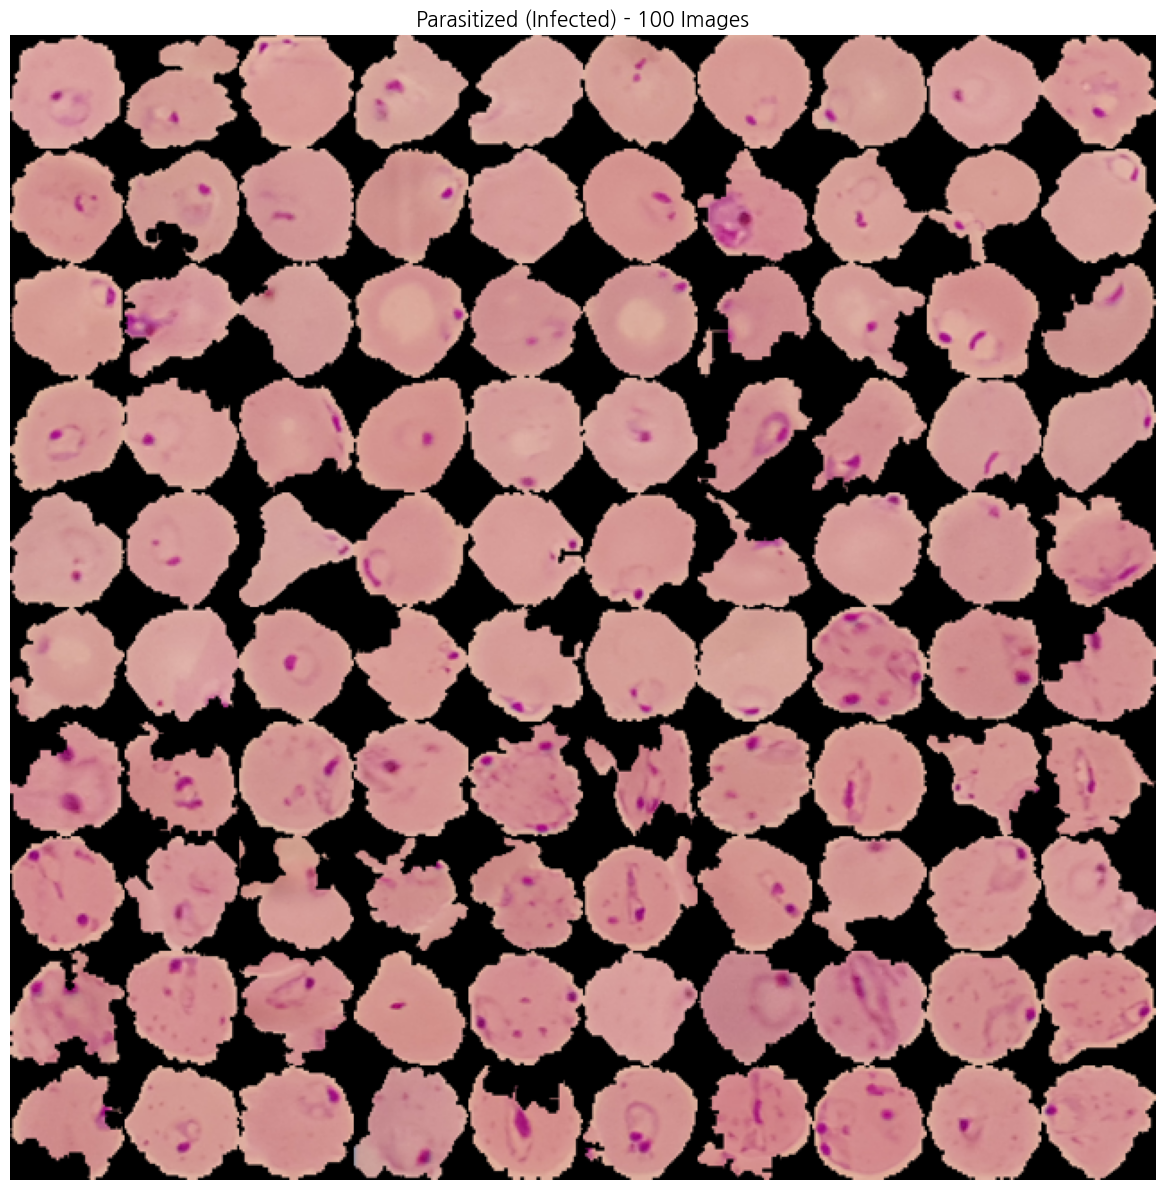

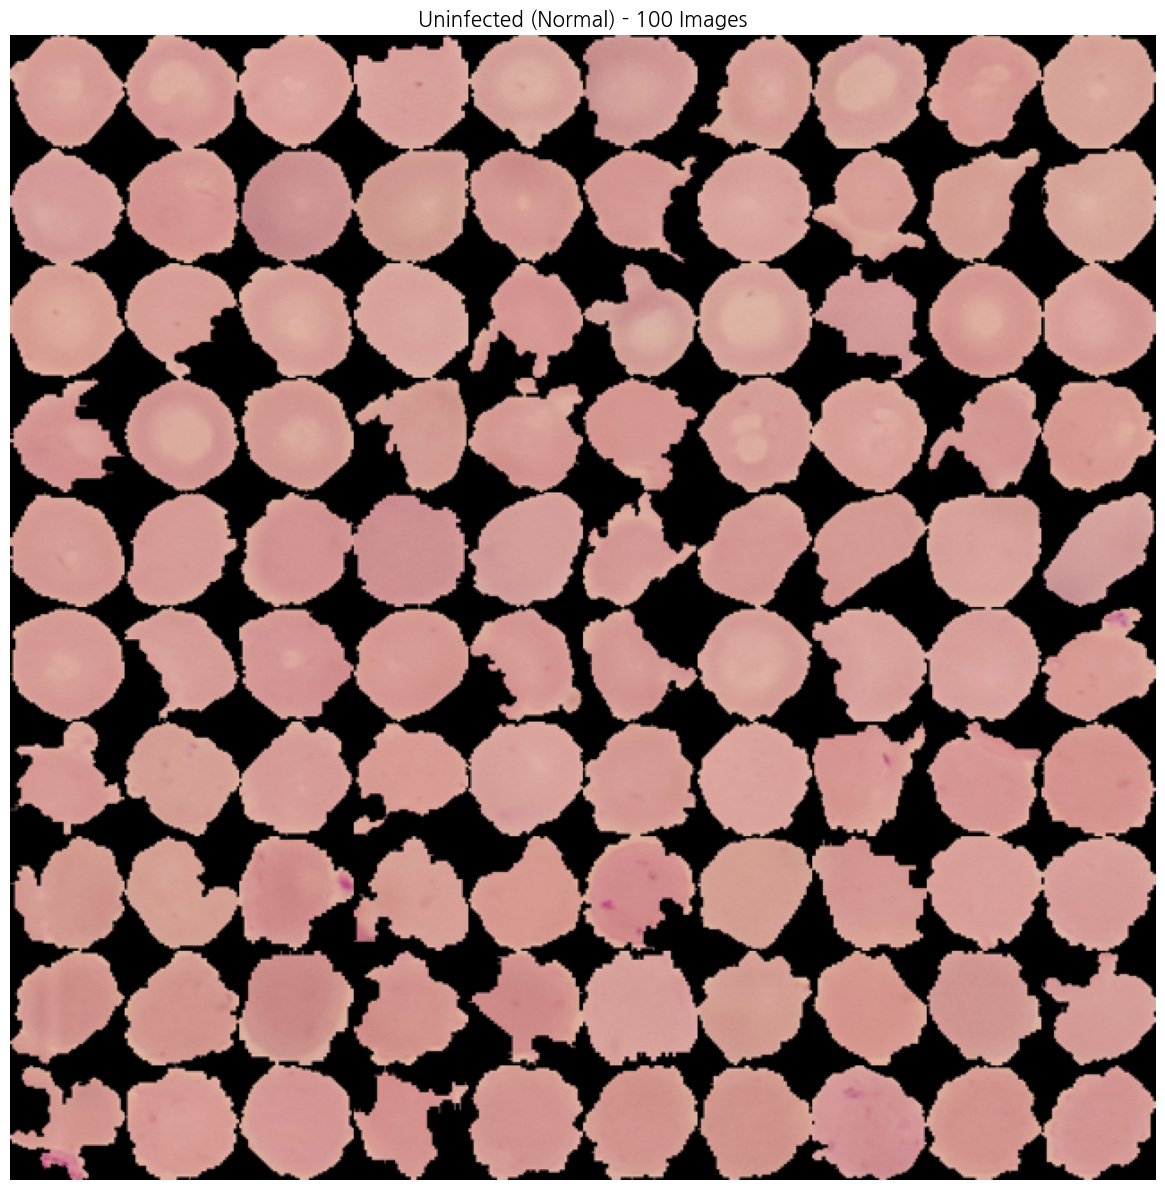

In [32]:
# 감염/정상 100장 확인

para_paths = sorted(glob.glob(os.path.join(BASE, 'Parasitized', '*.png')))[:100]
uninf_paths = sorted(glob.glob(os.path.join(BASE, 'Uninfected', '*.png')))[:100]

# ── 데이터 사이즈 확인 — 원본 이미지 해상도가 제각각인지 점검 ──
print('원본 이미지 크기 확인 (W x H):')
for name, paths in [('Parasitized', para_paths), ('Uninfected', uninf_paths)]:
    sizes = [Image.open(p).size for p in paths[:30]]   # 앞 30장 표본
    widths  = [s[0] for s in sizes]
    heights = [s[1] for s in sizes]
    print(f'  {name:12s}: '
          f'W {min(widths)}~{max(widths)}, H {min(heights)}~{max(heights)}  '
          f'(예: {sizes[0]}, {sizes[1]}, {sizes[2]})')
print('→ 세포 이미지는 원본 크기가 제각각입니다. 그래서 학습 전 Resize로 통일합니다.\n')

# ── 100장 격자 ──
def make_grid(paths, rows=10, cols=10, cell=64):
    grid = np.ones((rows*cell, cols*cell, 3)) * 255
    for i, p in enumerate(paths[:rows*cols]):
        img = np.array(Image.open(p).convert('RGB').resize((cell, cell)))
        r, c = divmod(i, cols)
        grid[r*cell:(r+1)*cell, c*cell:(c+1)*cell] = img
    return grid.astype(np.uint8)

for title, paths in [('Parasitized (Infected) - 100 Images', para_paths), ('Uninfected (Normal) - 100 Images', uninf_paths)]:
    plt.figure(figsize=(12, 12))
    plt.imshow(make_grid(paths))
    plt.title(title, fontsize=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [33]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    BASE,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(64, 64),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    BASE,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(64, 64),
    batch_size=32
)

class_names = train_ds.class_names

Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.


In [34]:
# 정규화
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# 확인
for images, labels in train_ds.take(1):
    print(images.numpy().min())
    print(images.numpy().max())

# 속도 최적화

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

0.0
0.96924025


In [35]:
# Augmentation
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="DataAugmentation")

In [36]:
# 모델링 (simple cnn + augmentation + dropout)

def create_complex_cnn():
    model = models.Sequential([
        layers.Input(shape=(64,64,3)),

        data_augmentation,

        layers.Conv2D(32,(3,3),padding='same',activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(64,(3,3),padding='same',activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(128,(3,3),padding='same',activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(256,activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(2)
    ])

    model.compile(
        optimizer='adam',
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    return model

In [37]:
# 학습 함수

def train_model(model, train_ds, val_ds, model_name="Model", epochs=10):
    print(f"===== Training {model_name} =====")

    history = model.fit(train_ds,validation_data=val_ds,epochs=epochs)

    print(f"===== {model_name} Training Finished =====")

    return history

In [38]:
# 평가 함수

def evaluate_model(model, val_ds, class_names, model_name="Model"):
    y_true = []
    y_pred = []

    for images, labels in val_ds:
        preds = model.predict(images, verbose=0)
        preds = np.argmax(preds, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = accuracy_score(y_true, y_pred)

    print(f"===== {model_name} Evaluation =====")
    print(f"Accuracy: {accuracy:.4f}")
    print()
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names
    ))

    return y_true, y_pred

In [39]:
# 혼동행렬

def plot_confusion_matrix(y_true, y_pred, class_names, model_name="Model", save=False):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        cmap="Blues",
        values_format="d"
    )

    plt.title(f"{model_name} Confusion Matrix")

    if save:
        plt.savefig(f"{model_name}_confusion_matrix.png", dpi=300, bbox_inches="tight")

    plt.show()

    return cm

In [40]:
# 바교 학습곡선

def compare_history(history1, history2, name1="Model1", name2="Model2"):

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy
    ax[0].plot(history1.history['accuracy'], marker='o', label=f'{name1} Train')
    ax[0].plot(history1.history['val_accuracy'], marker='s', label=f'{name1} Val')
    ax[0].plot(history2.history['accuracy'], marker='o', linestyle='--', label=f'{name2} Train')
    ax[0].plot(history2.history['val_accuracy'], marker='s', linestyle='--', label=f'{name2} Val')

    ax[0].set_title('Accuracy Comparison')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Accuracy')
    ax[0].legend()
    ax[0].grid(True)

    # Loss
    ax[1].plot(history1.history['loss'], marker='o', label=f'{name1} Train')
    ax[1].plot(history1.history['val_loss'], marker='s', label=f'{name1} Val')
    ax[1].plot(history2.history['loss'], marker='o', linestyle='--', label=f'{name2} Train')
    ax[1].plot(history2.history['val_loss'], marker='s', linestyle='--', label=f'{name2} Val')

    ax[1].set_title('Loss Comparison')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Loss')
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()

In [41]:
# 단일 학습곡선

def plot_history(history, model_name="Model"):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy
    ax[0].plot(history.history['accuracy'], marker='o', label='Train Accuracy')
    ax[0].plot(history.history['val_accuracy'], marker='s', label='Val Accuracy')
    ax[0].set_title(f'{model_name} Accuracy')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Accuracy')
    ax[0].legend()
    ax[0].grid(True)

    # Loss
    ax[1].plot(history.history['loss'], marker='o', label='Train Loss')
    ax[1].plot(history.history['val_loss'], marker='s', label='Val Loss')
    ax[1].set_title(f'{model_name} Loss')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Loss')
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()

# 학습시작

## 1막 전체학습

===== Training Full Data Model =====
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8045 - loss: 0.3848 - val_accuracy: 0.9532 - val_loss: 0.1501
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9503 - loss: 0.1610 - val_accuracy: 0.9497 - val_loss: 0.1551
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9541 - loss: 0.1455 - val_accuracy: 0.9494 - val_loss: 0.1442
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9561 - loss: 0.1390 - val_accuracy: 0.9543 - val_loss: 0.1388
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9559 - loss: 0.1373 - val_accuracy: 0.9583 - val_loss: 0.1273
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9574 - loss: 0.1316 - val_accuracy: 0.9570 - val_loss: 0.1303
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9572 - loss: 0.1297 - val_accuracy: 0.9523 - val_loss: 0.1385
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 

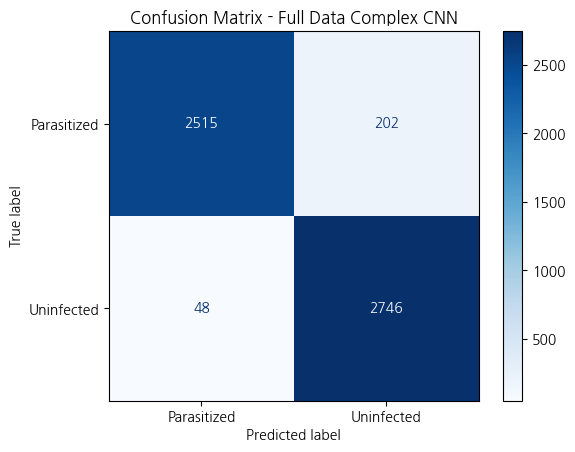

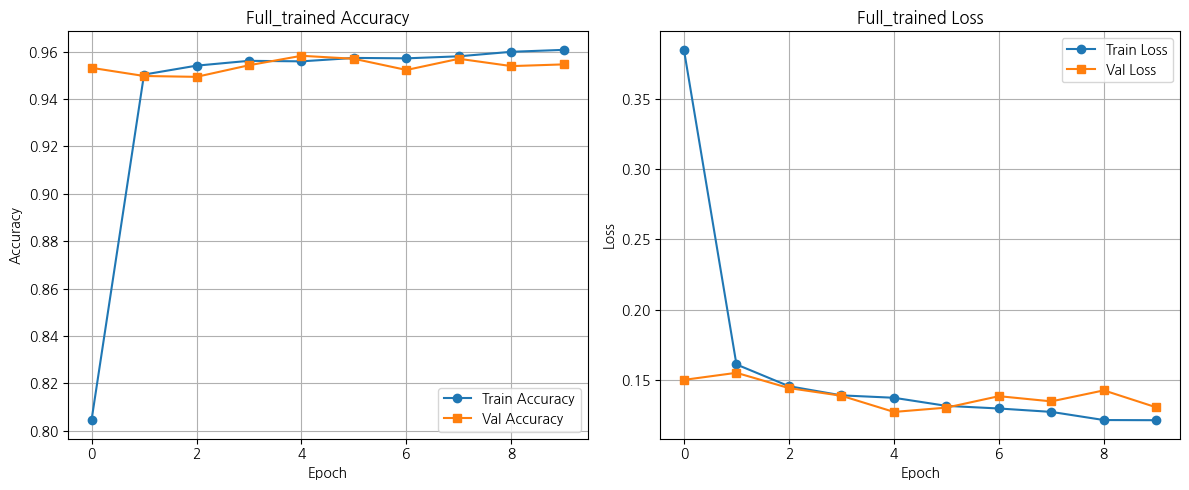

In [42]:
# 전체학습
model_full = create_complex_cnn()

history_full = train_model(
    model_full,
    train_ds,
    val_ds,
    model_name="Full Data Model",
    epochs=10
)
# 평가
y_true_full, y_pred_full = evaluate_model(
    model_full,
    val_ds,
    class_names,
    model_name="Full Data Complex CNN"
)

# 혼동행렬
cm = confusion_matrix(y_true_full, y_pred_full)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Full Data Complex CNN")
plt.show

plot_history(history_full,"Full_trained")

In [43]:
wrong_FN = []
wrong_FP = []

for images, labels in val_ds:
    preds = model_full.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    for img, true, pred in zip(images, labels.numpy(), preds):
        if true != pred:
            # Parasitized = 0
            if true == 0:
                wrong_FN.append((img, true, pred))
            # Uninfected = 1
            else:
                wrong_FP.append((img, true, pred))

print(f"False Negative (감염 놓침): {len(wrong_FN)}")
print(f"False Positive (정상 오판): {len(wrong_FP)}")

False Negative (감염 놓침): 202
False Positive (정상 오판): 48


## 틀린 샘플 모아보기

In [44]:
# 틀린샘플 출력

def show_wrong(samples, title, n=10):

    if len(samples) == 0:
        print(f"{title}: 없음")
        return

    n = min(n, len(samples))
    fig, axes = plt.subplots(1, n, figsize=(15, 2.5))
    axes = axes.flatten()

    for i in range(n):

        img, true, pred = samples[i]
        axes[i].imshow(img)
        axes[i].set_title(f"실제:{class_names[true]}\n예측:{class_names[pred]}",fontsize=8,color="red")
        axes[i].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

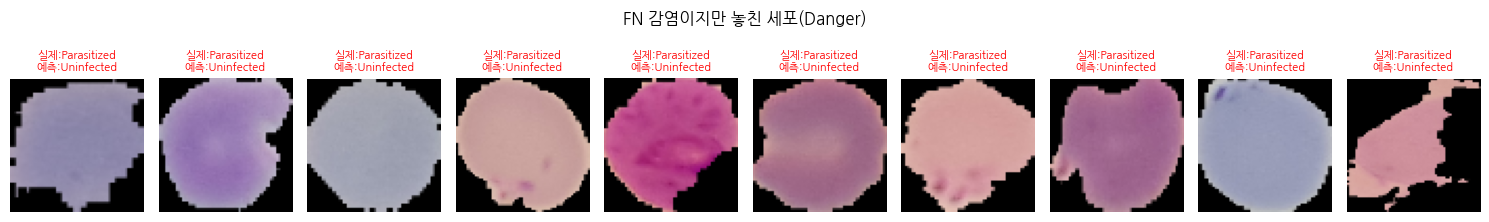

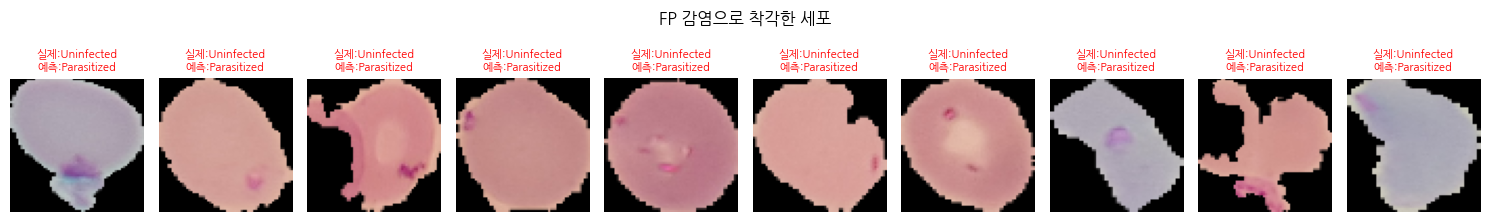

In [45]:
show_wrong(wrong_FN, "FN 감염이지만 놓친 세포(Danger)", n=10)
show_wrong(wrong_FP, "FP 감염으로 착각한 세포", n=10)

# Summarize

- False Nagative : 감염을 놓침

  
    아주 작은 점으로만 되어있고 거이 꺠끗해 보이는 세포들이 있다.

  
    즉, 모델이 놓친 건 기생충이 희미하거나 아주 작은 어려운 케이스들

  
    -> 모델의 성능보다는 데이터 자체가 어려운 경우

- False Positive : 감염이라 오판

  
    선명하게 얼룩이 진 것들이 많다.

  
    즉, 모델이 그것들을 기생충으로 판다.

  
    -> '보라색이 있으면 감염' 이라고 학습했음

#### Simple CNN의 경우에는 3개의 층으로 좀 더 깊게 학습하여 다 잡을 수 있도록 설계를 촘촘히 해야한다.(ResNet등)

## 2막 200장 학습

In [53]:
# 클래스별 파일 경로
para_paths = sorted(glob.glob(os.path.join(BASE, "Parasitized", "*.png")))
uninf_paths = sorted(glob.glob(os.path.join(BASE, "Uninfected", "*.png")))

N_PER_CLASS = 200
rng = np.random.default_rng(SEED)

para_200 = rng.choice(para_paths, N_PER_CLASS, replace=False)
uninf_200 = rng.choice(uninf_paths, N_PER_CLASS, replace=False)

small_paths = np.concatenate([para_200, uninf_200])
small_labels = np.array([0]*N_PER_CLASS + [1]*N_PER_CLASS)

idx = rng.permutation(len(small_paths))
small_paths = small_paths[idx]
small_labels = small_labels[idx]

print("공통 데이터:", len(small_paths), "장")
print("라벨 예시:", small_labels[:10])


def load_tf_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (64, 64))
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


train_ds_200 = tf.data.Dataset.from_tensor_slices(
    (small_paths, small_labels)
)

train_ds_200 = (
    train_ds_200
    .map(load_tf_image, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(400, seed=SEED)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

공통 데이터: 400 장
라벨 예시: [1 1 1 1 0 0 0 1 1 1]


===== Training Class 200 Images Model =====
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.4850 - loss: 0.7272 - val_accuracy: 0.5070 - val_loss: 0.6915
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.5250 - loss: 0.6925 - val_accuracy: 0.6246 - val_loss: 0.6851
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.6000 - loss: 0.6818 - val_accuracy: 0.4930 - val_loss: 0.7132
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.4925 - loss: 0.7159 - val_accuracy: 0.5077 - val_loss: 0.6909
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.4975 - loss: 0.6926 - val_accuracy: 0.5451 - val_loss: 0.6909
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.5150 - loss: 0.6918 - val_accuracy: 0.5295 - val_loss: 0.6890
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.5700 - loss: 0.6878 - val_accuracy: 0.4930 - val_loss: 0.6979
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.52

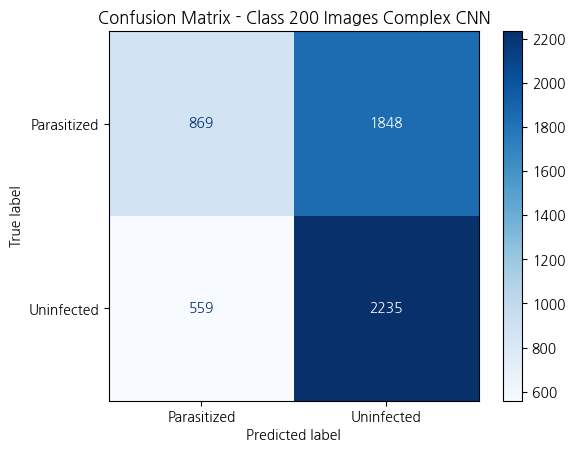

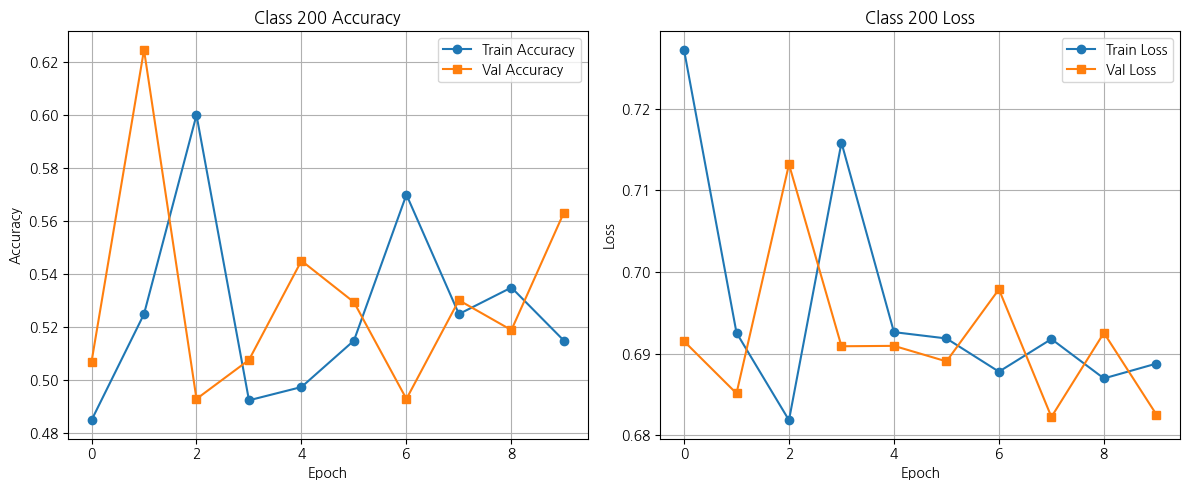

In [54]:
# 200장 학습
model_200 = create_complex_cnn()

history_200 = train_model(model_200,train_ds_200,val_ds,model_name="Class 200 Images Model",epochs=10)
y_true_200, y_pred_200 = evaluate_model(model_200,val_ds,class_names,model_name="Class 200 Images Complex CNN")

cm = confusion_matrix(y_true_200, y_pred_200)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=class_names)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Class 200 Images Complex CNN")
plt.show()

plot_history(history_200, "Class 200")

# Full, 200 비교

In [55]:
def compare_val_accuracy(history_full, history_200):

    plt.figure(figsize=(8,5))

    plt.plot(history_full.history['val_accuracy'],marker='o',label='Full Data')
    plt.plot(history_200.history['val_accuracy'],marker='s',label='200 Images')

    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.legend()
    plt.grid(True)

    plt.show()

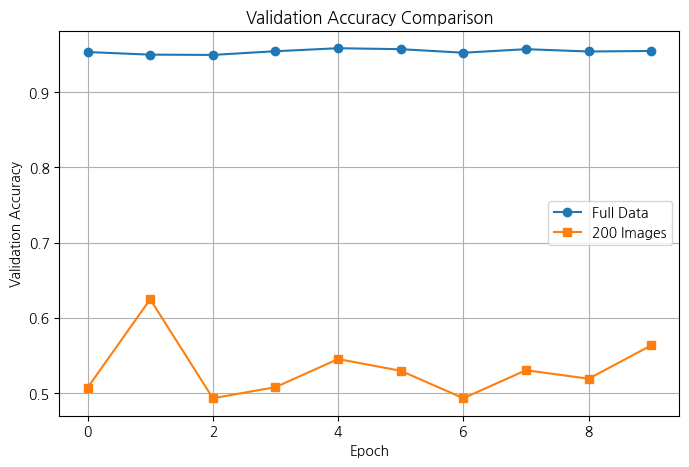

In [56]:
compare_val_accuracy(history_full, history_200)